# Hybrid Beam Forming using a Multilayer Perceptron 

## Load Helpers 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import json 
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader, random_split 

import mitsuba as mi
mi.set_variant("cuda_ad_mono_polarized")
# mi.set_variant("llvm_ad_rgb"); 

from sionna.rt import PathSolver

import os 
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "scripts")); 
sys.path.append(str(Path.cwd().parent / "outputs")); 
from dataset_handler import DatasetHandler 
from mlp import MLP 
from generate_raynet_dataset_v3 import (
    CONFIG,
    setup_scene,
    make_tx_positions,
    make_candidate_configs,
    sample_two_users_for_target_class,
    trace_four_links,
    score_all_joint_configs,
    target_class_passes,
    thermal_noise_watts,
    dbm_to_watts,
) 

### Parameters 

In [2]:
MODEL_CONFIG = {
    "input": 8, 
    "h1_dim": 128, 
    "h2_dim": 128, 
    "h3_dim": 64, 
    "out_1": len(CONFIG["sector_angles_deg"]),
    "out_2": CONFIG["num_codebooks"]
}; 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); 
print(f"Device: {DEVICE}"); 

BATCH_SIZE = 32; 
EPOCHS = 100; 
LR = 1e-2; 
lr_str = str(LR).replace("0.", ""); 

Device: cuda


## Train MLP 

Epoch [1/100] Loss: 3.2936
Epoch [2/100] Loss: 2.8837
Epoch [3/100] Loss: 2.7934
Epoch [4/100] Loss: 2.7412
Epoch [5/100] Loss: 2.7064
Epoch [6/100] Loss: 2.6970
Epoch [7/100] Loss: 2.6676
Epoch [8/100] Loss: 2.6506
Epoch [9/100] Loss: 2.6441
Epoch [10/100] Loss: 2.6339
Epoch [11/100] Loss: 2.6241
Epoch [12/100] Loss: 2.6188
Epoch [13/100] Loss: 2.6204
Epoch [14/100] Loss: 2.6066
Epoch [15/100] Loss: 2.6085
Epoch [16/100] Loss: 2.5946
Epoch [17/100] Loss: 2.5914
Epoch [18/100] Loss: 2.5940
Epoch [19/100] Loss: 2.5899
Epoch [20/100] Loss: 2.5919
Epoch [21/100] Loss: 2.5895
Epoch [22/100] Loss: 2.5785
Epoch [23/100] Loss: 2.5940
Epoch [24/100] Loss: 2.5916
Epoch [25/100] Loss: 2.5774
Epoch [26/100] Loss: 2.5844
Epoch [27/100] Loss: 2.5746
Epoch [28/100] Loss: 2.5704
Epoch [29/100] Loss: 2.5768
Epoch [30/100] Loss: 2.5685
Epoch [31/100] Loss: 2.5768
Epoch [32/100] Loss: 2.5872
Epoch [33/100] Loss: 2.5768
Epoch [34/100] Loss: 2.5659
Epoch [35/100] Loss: 2.5693
Epoch [36/100] Loss: 2.5843
E

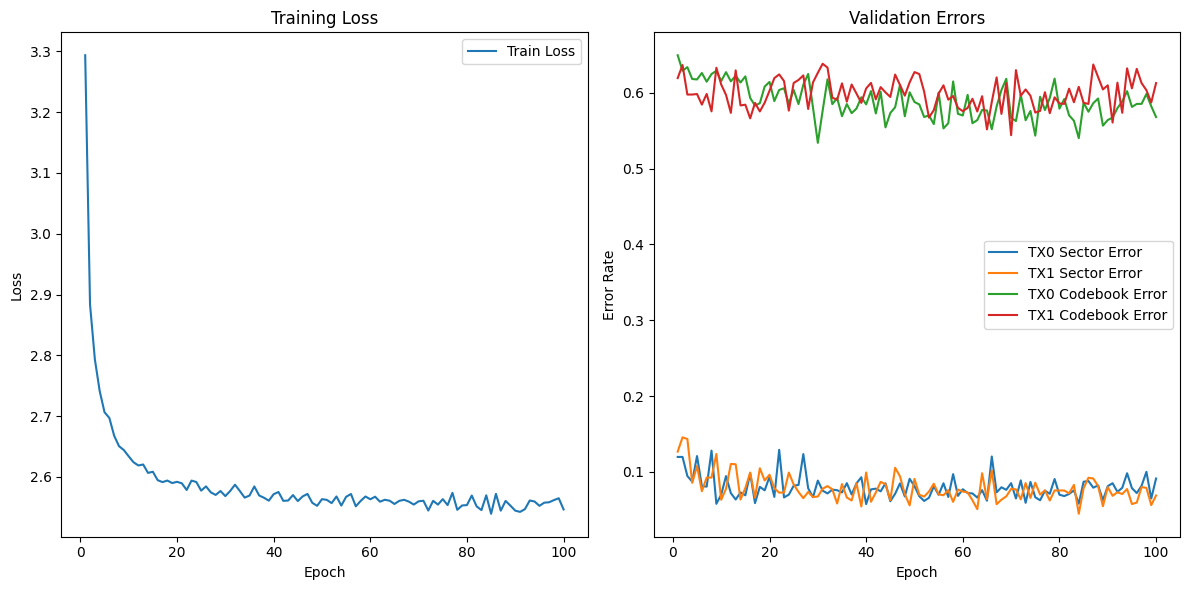

Epoch [1/100] Loss: 3.2720
Epoch [2/100] Loss: 2.8358
Epoch [3/100] Loss: 2.7685
Epoch [4/100] Loss: 2.7079
Epoch [5/100] Loss: 2.6543
Epoch [6/100] Loss: 2.6074
Epoch [7/100] Loss: 2.5681
Epoch [8/100] Loss: 2.5274
Epoch [9/100] Loss: 2.5057
Epoch [10/100] Loss: 2.4505
Epoch [11/100] Loss: 2.4500
Epoch [12/100] Loss: 2.4216
Epoch [13/100] Loss: 2.3872
Epoch [14/100] Loss: 2.3983
Epoch [15/100] Loss: 2.3262
Epoch [16/100] Loss: 2.2982
Epoch [17/100] Loss: 2.2601
Epoch [18/100] Loss: 2.2561
Epoch [19/100] Loss: 2.2066
Epoch [20/100] Loss: 2.1719
Epoch [21/100] Loss: 2.1771
Epoch [22/100] Loss: 2.1686
Epoch [23/100] Loss: 2.1453
Epoch [24/100] Loss: 2.1624
Epoch [25/100] Loss: 2.1394
Epoch [26/100] Loss: 2.1215
Epoch [27/100] Loss: 2.1277
Epoch [28/100] Loss: 2.1224
Epoch [29/100] Loss: 2.1108
Epoch [30/100] Loss: 2.1041
Epoch [31/100] Loss: 2.1230
Epoch [32/100] Loss: 2.0885
Epoch [33/100] Loss: 2.0810
Epoch [34/100] Loss: 2.0974
Epoch [35/100] Loss: 2.0917
Epoch [36/100] Loss: 2.0861
E

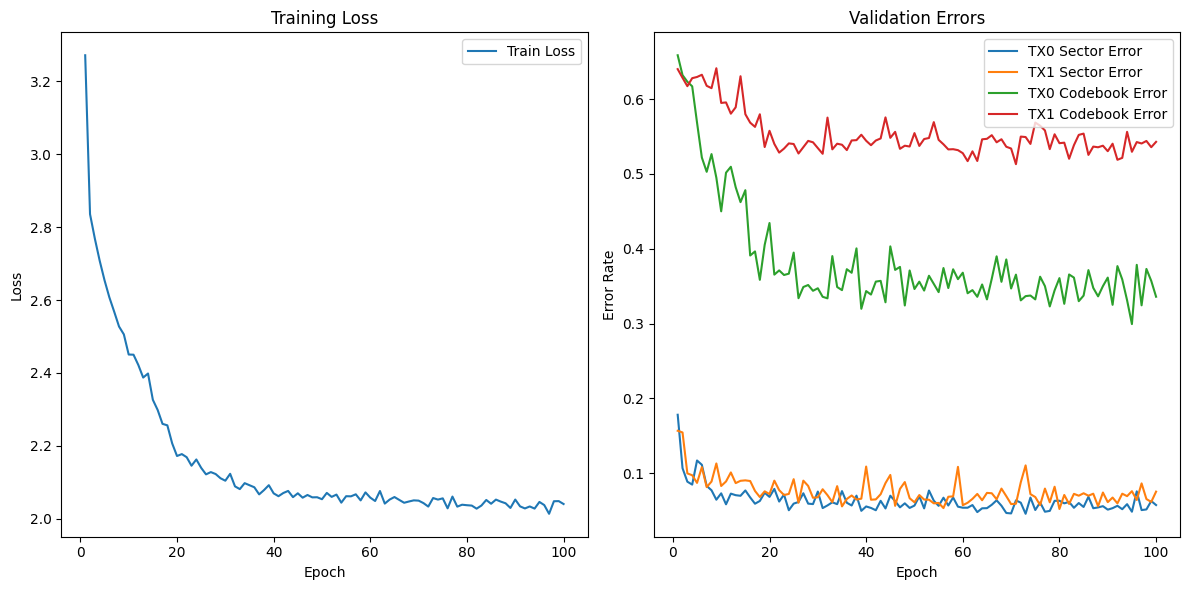

Epoch [1/100] Loss: 3.3308
Epoch [2/100] Loss: 2.7746
Epoch [3/100] Loss: 2.6767
Epoch [4/100] Loss: 2.6304
Epoch [5/100] Loss: 2.5695
Epoch [6/100] Loss: 2.5193
Epoch [7/100] Loss: 2.4453
Epoch [8/100] Loss: 2.3698
Epoch [9/100] Loss: 2.2930
Epoch [10/100] Loss: 2.1891
Epoch [11/100] Loss: 2.1510
Epoch [12/100] Loss: 2.0996
Epoch [13/100] Loss: 2.0677
Epoch [14/100] Loss: 2.0587
Epoch [15/100] Loss: 2.0292
Epoch [16/100] Loss: 1.9954
Epoch [17/100] Loss: 1.9886
Epoch [18/100] Loss: 1.9712
Epoch [19/100] Loss: 1.9626
Epoch [20/100] Loss: 1.9449
Epoch [21/100] Loss: 1.9269
Epoch [22/100] Loss: 1.9196
Epoch [23/100] Loss: 1.9010
Epoch [24/100] Loss: 1.8984
Epoch [25/100] Loss: 1.8930
Epoch [26/100] Loss: 1.9003
Epoch [27/100] Loss: 1.8715
Epoch [28/100] Loss: 1.8871
Epoch [29/100] Loss: 1.8671
Epoch [30/100] Loss: 1.8413
Epoch [31/100] Loss: 1.8653
Epoch [32/100] Loss: 1.8402
Epoch [33/100] Loss: 1.8558
Epoch [34/100] Loss: 1.8404
Epoch [35/100] Loss: 1.8266
Epoch [36/100] Loss: 1.8321
E

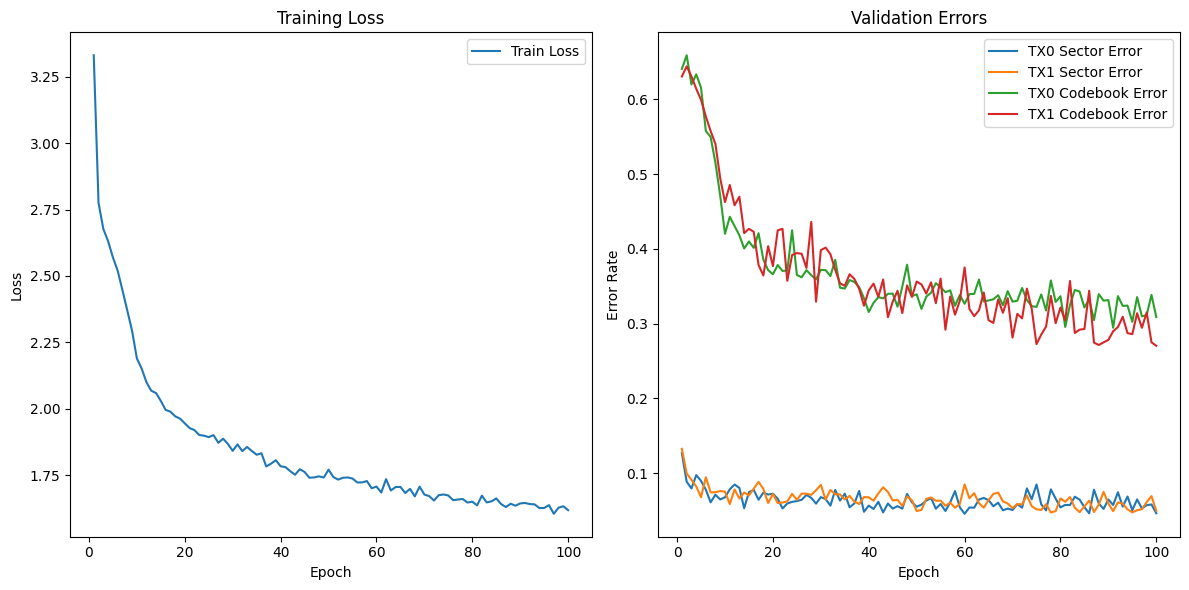

Epoch [1/100] Loss: 3.1919
Epoch [2/100] Loss: 2.7458
Epoch [3/100] Loss: 2.6064
Epoch [4/100] Loss: 2.5098
Epoch [5/100] Loss: 2.4123
Epoch [6/100] Loss: 2.2821
Epoch [7/100] Loss: 2.1034
Epoch [8/100] Loss: 1.9601
Epoch [9/100] Loss: 1.8153
Epoch [10/100] Loss: 1.6959
Epoch [11/100] Loss: 1.6048
Epoch [12/100] Loss: 1.5209
Epoch [13/100] Loss: 1.4603
Epoch [14/100] Loss: 1.3922
Epoch [15/100] Loss: 1.3533
Epoch [16/100] Loss: 1.3113
Epoch [17/100] Loss: 1.2678
Epoch [18/100] Loss: 1.2482
Epoch [19/100] Loss: 1.2151
Epoch [20/100] Loss: 1.1991
Epoch [21/100] Loss: 1.1723
Epoch [22/100] Loss: 1.1523
Epoch [23/100] Loss: 1.1449
Epoch [24/100] Loss: 1.1215
Epoch [25/100] Loss: 1.1089
Epoch [26/100] Loss: 1.0747
Epoch [27/100] Loss: 1.0321
Epoch [28/100] Loss: 1.0413
Epoch [29/100] Loss: 1.0170
Epoch [30/100] Loss: 1.0015
Epoch [31/100] Loss: 0.9896
Epoch [32/100] Loss: 0.9887
Epoch [33/100] Loss: 0.9792
Epoch [34/100] Loss: 0.9741
Epoch [35/100] Loss: 0.9639
Epoch [36/100] Loss: 0.9537
E

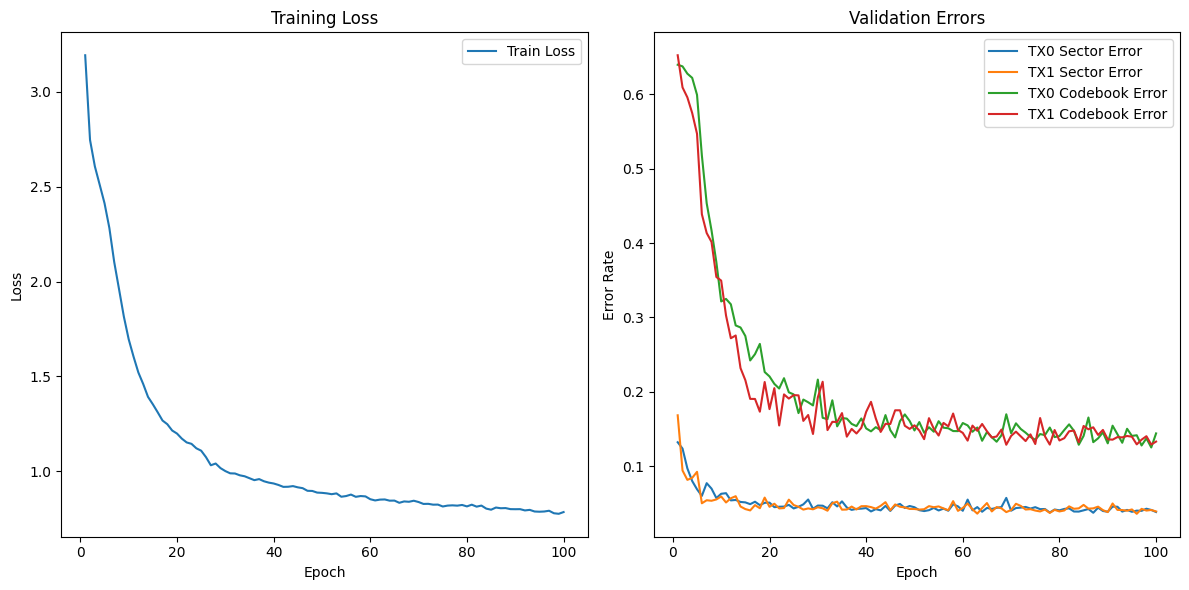

Epoch [1/100] Loss: 3.2797
Epoch [2/100] Loss: 2.7615
Epoch [3/100] Loss: 2.6345
Epoch [4/100] Loss: 2.5523
Epoch [5/100] Loss: 2.5024
Epoch [6/100] Loss: 2.4357
Epoch [7/100] Loss: 2.3729
Epoch [8/100] Loss: 2.2951
Epoch [9/100] Loss: 2.2096
Epoch [10/100] Loss: 2.1140
Epoch [11/100] Loss: 2.0090
Epoch [12/100] Loss: 1.8966
Epoch [13/100] Loss: 1.8053
Epoch [14/100] Loss: 1.7358
Epoch [15/100] Loss: 1.6621
Epoch [16/100] Loss: 1.5928
Epoch [17/100] Loss: 1.5407
Epoch [18/100] Loss: 1.4813
Epoch [19/100] Loss: 1.4288
Epoch [20/100] Loss: 1.3872
Epoch [21/100] Loss: 1.3654
Epoch [22/100] Loss: 1.3167
Epoch [23/100] Loss: 1.2877
Epoch [24/100] Loss: 1.2743
Epoch [25/100] Loss: 1.2183
Epoch [26/100] Loss: 1.2002
Epoch [27/100] Loss: 1.1653
Epoch [28/100] Loss: 1.1437
Epoch [29/100] Loss: 1.1104
Epoch [30/100] Loss: 1.0685
Epoch [31/100] Loss: 1.0772
Epoch [32/100] Loss: 1.0243
Epoch [33/100] Loss: 1.0135
Epoch [34/100] Loss: 0.9920
Epoch [35/100] Loss: 0.9805
Epoch [36/100] Loss: 0.9694
E

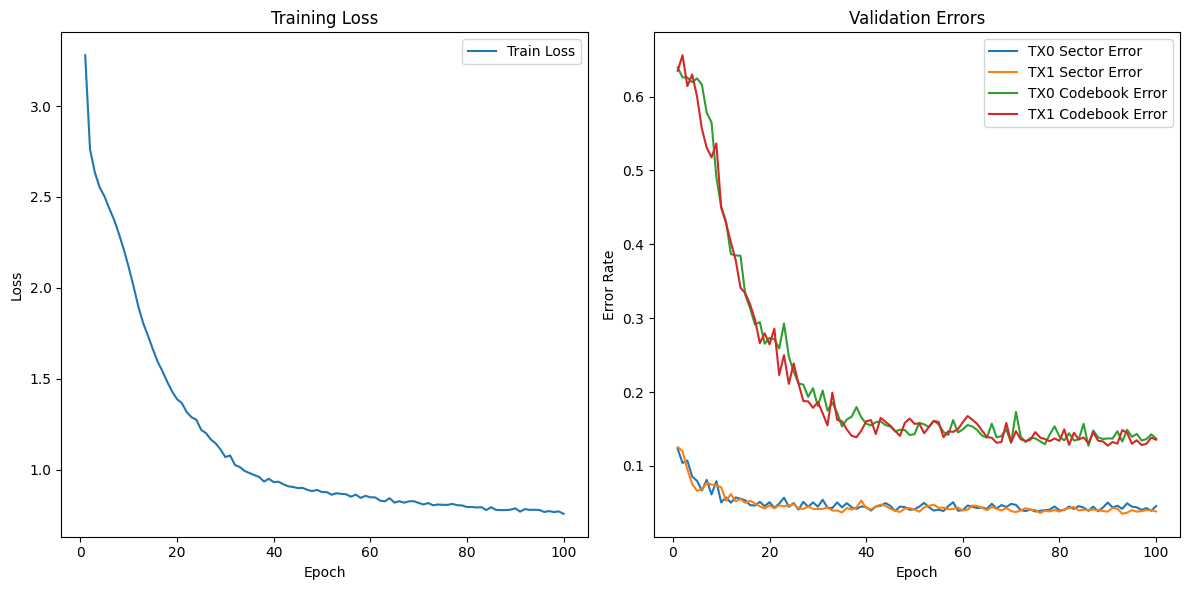

Epoch [1/100] Loss: 3.5289
Epoch [2/100] Loss: 2.8607
Epoch [3/100] Loss: 2.7309
Epoch [4/100] Loss: 2.6637
Epoch [5/100] Loss: 2.5996
Epoch [6/100] Loss: 2.5502
Epoch [7/100] Loss: 2.5100
Epoch [8/100] Loss: 2.4797
Epoch [9/100] Loss: 2.4507
Epoch [10/100] Loss: 2.4167
Epoch [11/100] Loss: 2.3804
Epoch [12/100] Loss: 2.3525
Epoch [13/100] Loss: 2.2800
Epoch [14/100] Loss: 2.2314
Epoch [15/100] Loss: 2.1772
Epoch [16/100] Loss: 2.0984
Epoch [17/100] Loss: 2.0455
Epoch [18/100] Loss: 1.9939
Epoch [19/100] Loss: 1.9336
Epoch [20/100] Loss: 1.8753
Epoch [21/100] Loss: 1.8404
Epoch [22/100] Loss: 1.7832
Epoch [23/100] Loss: 1.7547
Epoch [24/100] Loss: 1.7190
Epoch [25/100] Loss: 1.6757
Epoch [26/100] Loss: 1.6353
Epoch [27/100] Loss: 1.5867
Epoch [28/100] Loss: 1.5408
Epoch [29/100] Loss: 1.5120
Epoch [30/100] Loss: 1.4632
Epoch [31/100] Loss: 1.4193
Epoch [32/100] Loss: 1.3775
Epoch [33/100] Loss: 1.3447
Epoch [34/100] Loss: 1.2996
Epoch [35/100] Loss: 1.2785
Epoch [36/100] Loss: 1.2424
E

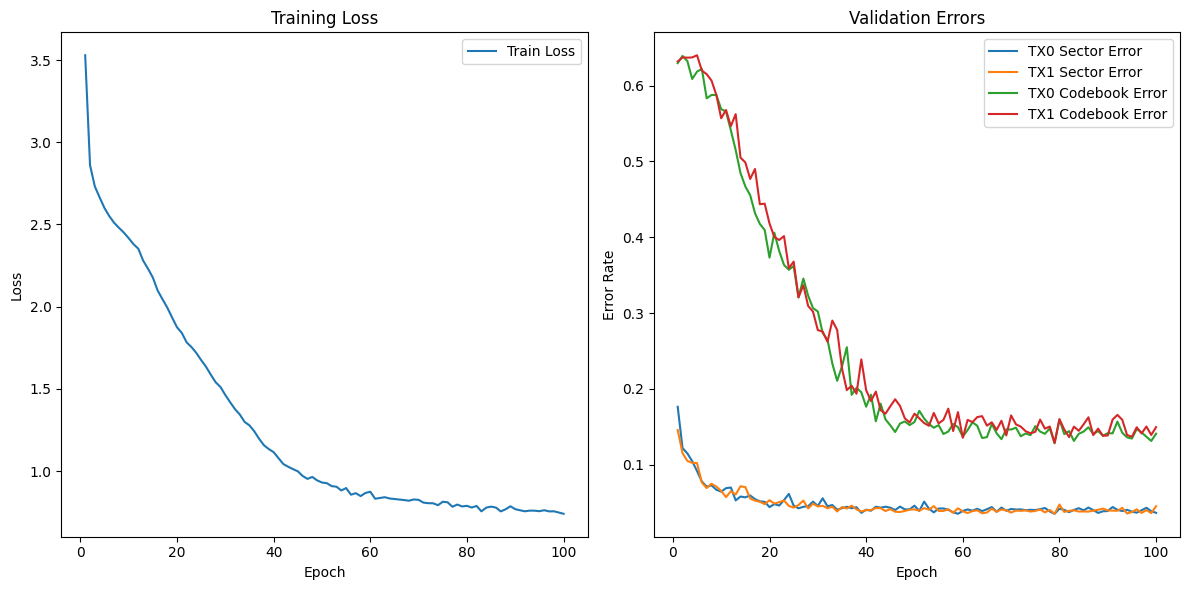

Epoch [1/100] Loss: 4.0588
Epoch [2/100] Loss: 3.2479
Epoch [3/100] Loss: 2.9879
Epoch [4/100] Loss: 2.8613
Epoch [5/100] Loss: 2.7788
Epoch [6/100] Loss: 2.7226
Epoch [7/100] Loss: 2.6824
Epoch [8/100] Loss: 2.6543
Epoch [9/100] Loss: 2.6310
Epoch [10/100] Loss: 2.6093
Epoch [11/100] Loss: 2.5942
Epoch [12/100] Loss: 2.5775
Epoch [13/100] Loss: 2.5638
Epoch [14/100] Loss: 2.5473
Epoch [15/100] Loss: 2.5313
Epoch [16/100] Loss: 2.5201
Epoch [17/100] Loss: 2.5019
Epoch [18/100] Loss: 2.4900
Epoch [19/100] Loss: 2.4715
Epoch [20/100] Loss: 2.4574
Epoch [21/100] Loss: 2.4402
Epoch [22/100] Loss: 2.4217
Epoch [23/100] Loss: 2.4045
Epoch [24/100] Loss: 2.3835
Epoch [25/100] Loss: 2.3610
Epoch [26/100] Loss: 2.3430
Epoch [27/100] Loss: 2.3232
Epoch [28/100] Loss: 2.3053
Epoch [29/100] Loss: 2.2850
Epoch [30/100] Loss: 2.2641
Epoch [31/100] Loss: 2.2485
Epoch [32/100] Loss: 2.2295
Epoch [33/100] Loss: 2.2107
Epoch [34/100] Loss: 2.1960
Epoch [35/100] Loss: 2.1775
Epoch [36/100] Loss: 2.1669
E

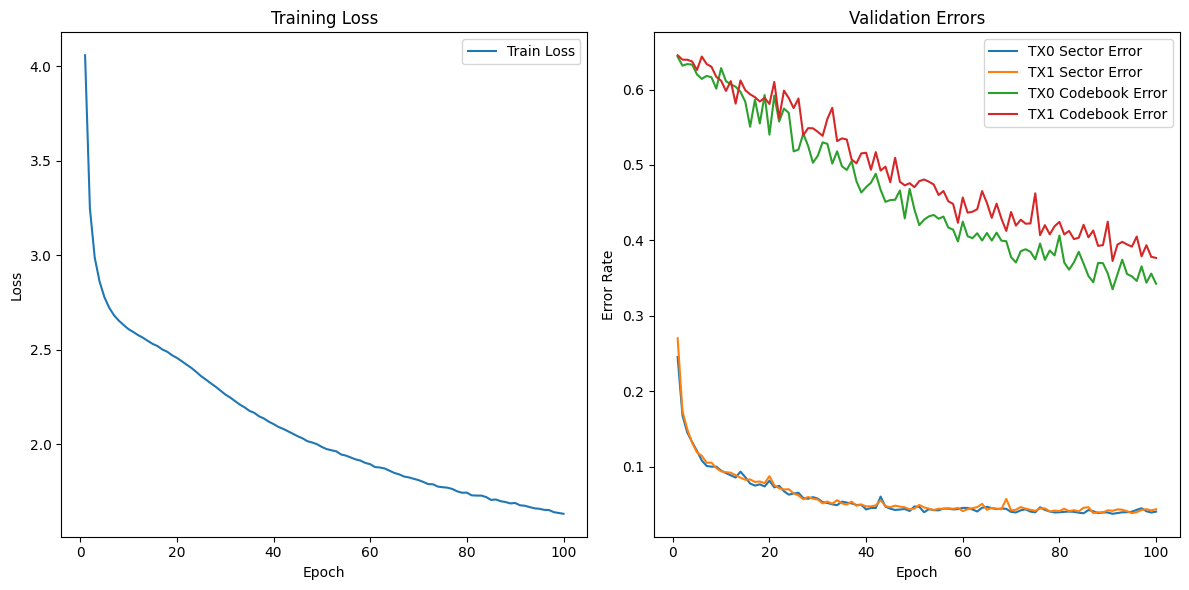

Epoch [1/100] Loss: 4.4055
Epoch [2/100] Loss: 3.4685
Epoch [3/100] Loss: 3.1577
Epoch [4/100] Loss: 2.9958
Epoch [5/100] Loss: 2.8992
Epoch [6/100] Loss: 2.8305
Epoch [7/100] Loss: 2.7778
Epoch [8/100] Loss: 2.7361
Epoch [9/100] Loss: 2.7049
Epoch [10/100] Loss: 2.6762
Epoch [11/100] Loss: 2.6545
Epoch [12/100] Loss: 2.6390
Epoch [13/100] Loss: 2.6246
Epoch [14/100] Loss: 2.6093
Epoch [15/100] Loss: 2.5955
Epoch [16/100] Loss: 2.5824
Epoch [17/100] Loss: 2.5705
Epoch [18/100] Loss: 2.5574
Epoch [19/100] Loss: 2.5474
Epoch [20/100] Loss: 2.5408
Epoch [21/100] Loss: 2.5275
Epoch [22/100] Loss: 2.5186
Epoch [23/100] Loss: 2.5078
Epoch [24/100] Loss: 2.4967
Epoch [25/100] Loss: 2.4883
Epoch [26/100] Loss: 2.4802
Epoch [27/100] Loss: 2.4658
Epoch [28/100] Loss: 2.4570
Epoch [29/100] Loss: 2.4493
Epoch [30/100] Loss: 2.4405
Epoch [31/100] Loss: 2.4302
Epoch [32/100] Loss: 2.4208
Epoch [33/100] Loss: 2.4104
Epoch [34/100] Loss: 2.4004
Epoch [35/100] Loss: 2.3907
Epoch [36/100] Loss: 2.3779
E

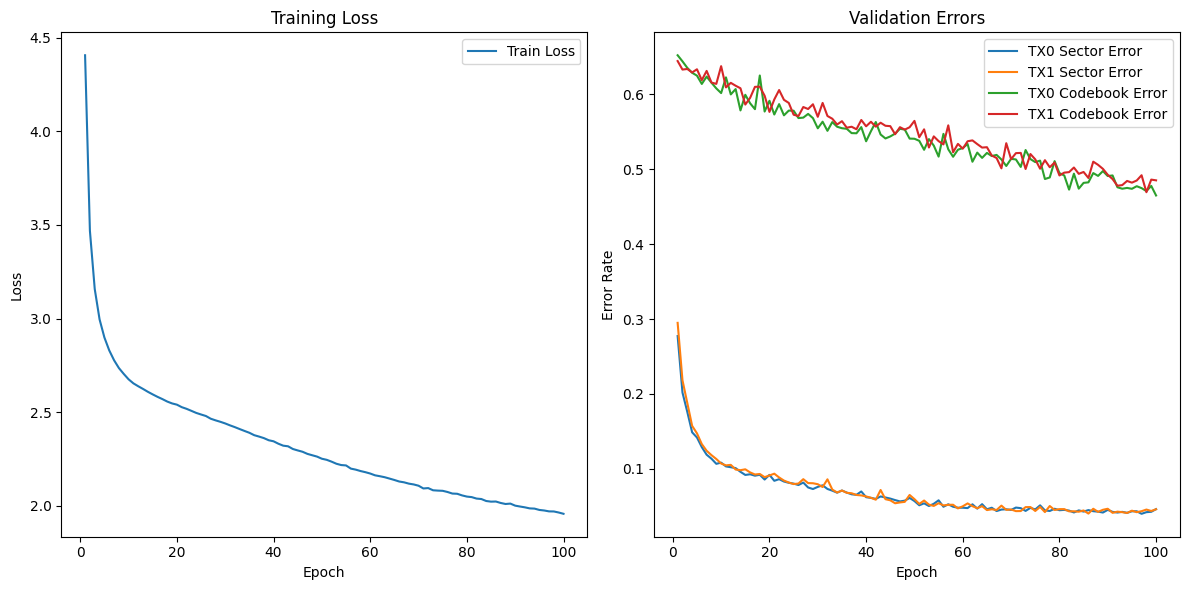

Epoch [1/100] Loss: 4.7712
Epoch [2/100] Loss: 3.7670
Epoch [3/100] Loss: 3.3975
Epoch [4/100] Loss: 3.1779
Epoch [5/100] Loss: 3.0409
Epoch [6/100] Loss: 2.9550
Epoch [7/100] Loss: 2.8917
Epoch [8/100] Loss: 2.8430
Epoch [9/100] Loss: 2.8073
Epoch [10/100] Loss: 2.7681
Epoch [11/100] Loss: 2.7394
Epoch [12/100] Loss: 2.7170
Epoch [13/100] Loss: 2.6942
Epoch [14/100] Loss: 2.6771
Epoch [15/100] Loss: 2.6599
Epoch [16/100] Loss: 2.6475
Epoch [17/100] Loss: 2.6329
Epoch [18/100] Loss: 2.6210
Epoch [19/100] Loss: 2.6054
Epoch [20/100] Loss: 2.5993
Epoch [21/100] Loss: 2.5878
Epoch [22/100] Loss: 2.5796
Epoch [23/100] Loss: 2.5674
Epoch [24/100] Loss: 2.5575
Epoch [25/100] Loss: 2.5481
Epoch [26/100] Loss: 2.5380
Epoch [27/100] Loss: 2.5305
Epoch [28/100] Loss: 2.5199
Epoch [29/100] Loss: 2.5115
Epoch [30/100] Loss: 2.5002
Epoch [31/100] Loss: 2.4910
Epoch [32/100] Loss: 2.4835
Epoch [33/100] Loss: 2.4745
Epoch [34/100] Loss: 2.4665
Epoch [35/100] Loss: 2.4567
Epoch [36/100] Loss: 2.4500
E

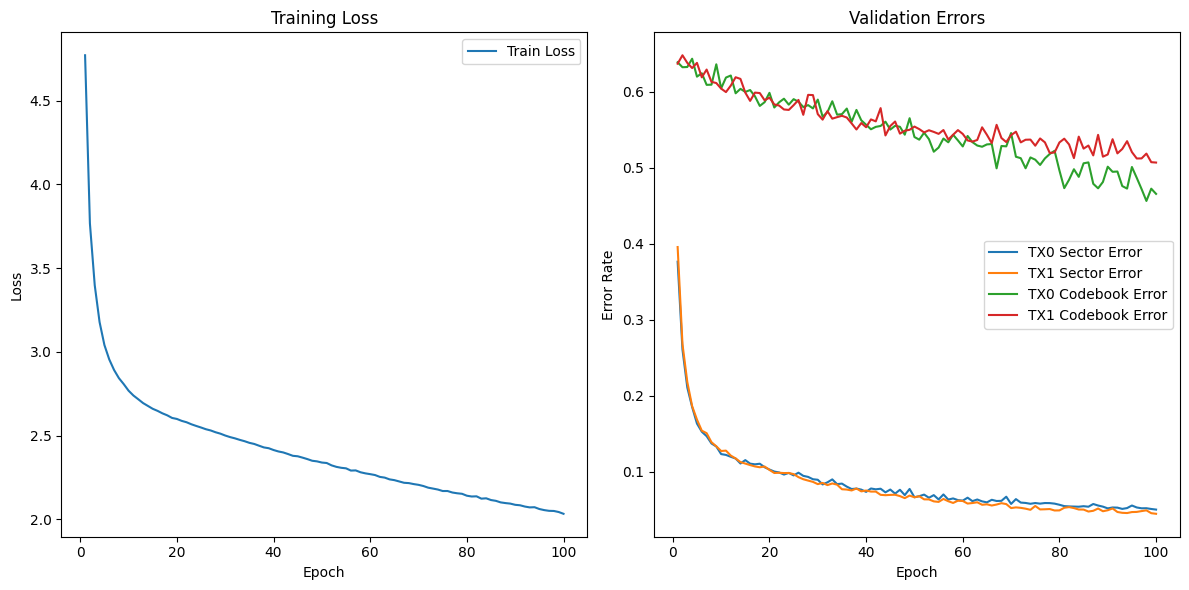

In [3]:
def plot_training_curves(train_losses, val_metrics, model_name): # Helper to plot train loss and validation error 

    epochs = range(1, len(train_losses) + 1); 

    plt.figure(figsize=(12, 6)); 

    # Train loss
    plt.subplot(1, 2, 1); 
    plt.plot(epochs, train_losses, label = "Train Loss"); 
    plt.xlabel("Epoch"); 
    plt.ylabel("Loss"); 
    plt.title("Training Loss"); 
    plt.legend(); 

    # Validation error 
    plt.subplot(1, 2, 2); 
    plt.plot(epochs, val_metrics["tx0_sector"], label = "TX0 Sector Error"); 
    plt.plot(epochs, val_metrics["tx1_sector"], label = "TX1 Sector Error"); 
    plt.plot(epochs, val_metrics["tx0_codebook"], label = "TX0 Codebook Error"); 
    plt.plot(epochs, val_metrics["tx1_codebook"], label = "TX1 Codebook Error"); 

    plt.xlabel("Epoch"); 
    plt.ylabel("Error Rate"); 
    plt.title("Validation Errors"); 
    plt.legend(); 

    plt.tight_layout(); 
    plt_path = f"../figures/{model_name}_loss_curves.png"; 
    plt.savefig(plt_path); 
    plt.show(); 
    plt.close(); 


def train(trainset, model_name): 

    dataset = DatasetHandler(trainset); 

    train_size = int(0.8 * len(dataset)); 
    val_size = len(dataset) - train_size; 

    train_set, val_set = random_split(
        dataset,
        [train_size, val_size]
    ); 

    train_loader = DataLoader(
        train_set,
        batch_size = BATCH_SIZE,
        shuffle = True
    ); 

    val_loader = DataLoader(
        val_set,
        batch_size = BATCH_SIZE,
        shuffle = False
    ); 

    model = MLP(
        input = MODEL_CONFIG["input"],
        h1_dim = MODEL_CONFIG["h1_dim"],
        h2_dim = MODEL_CONFIG["h2_dim"],
        h3_dim = MODEL_CONFIG["h3_dim"],
        out_1 = MODEL_CONFIG["out_1"],
        out_2 = MODEL_CONFIG["out_2"],
    ).to(DEVICE); 

    criterion = nn.CrossEntropyLoss(); 

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr = LR
    ); 

    train_losses = []; 

    val_tx0_sector = []; 
    val_tx1_sector = []; 
    val_tx0_codebook = []; 
    val_tx1_codebook = []; 

    for epoch in range(EPOCHS):

        model.train(); 

        running_loss = 0.0; 

        for (
            x,
            tx0_sector,
            tx1_sector,
            tx0_codebook,
            tx1_codebook
        ) in train_loader:

            x = x.to(DEVICE); 

            tx0_sector = tx0_sector.to(DEVICE); 
            tx1_sector = tx1_sector.to(DEVICE); 

            tx0_codebook = tx0_codebook.to(DEVICE); 
            tx1_codebook = tx1_codebook.to(DEVICE); 

            optimizer.zero_grad(); 

            s0, s1, c0, c1 = model(x); 

            loss_s0 = criterion(s0, tx0_sector); 
            loss_s1 = criterion(s1, tx1_sector); 

            loss_c0 = criterion(c0, tx0_codebook); 
            loss_c1 = criterion(c1, tx1_codebook); 

            loss = (
                loss_s0
                + loss_s1
                + loss_c0
                + loss_c1
            ); 

            loss.backward(); 
            optimizer.step(); 

            running_loss += loss.item(); 

        avg_train_loss = running_loss / len(train_loader); 
        train_losses.append(avg_train_loss); 

        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Loss: {avg_train_loss:.4f}"
        ); 

        # Test on validation set 
        model.eval(); 

        correct_tx0_s = 0; 
        total_tx0_s = 0; 

        correct_tx1_s = 0; 
        total_tx1_s = 0; 

        correct_tx0_c = 0; 
        total_tx0_c = 0; 

        correct_tx1_c = 0; 
        total_tx1_c = 0; 

        with torch.no_grad(): 
            for (
                x,
                tx0_sector,
                tx1_sector,
                tx0_codebook,
                tx1_codebook
            ) in val_loader: 

                x = x.to(DEVICE); 
                tx0_sector = tx0_sector.to(DEVICE); 
                tx1_sector = tx1_sector.to(DEVICE); 
                tx0_codebook = tx0_codebook.to(DEVICE); 
                tx1_codebook = tx1_codebook.to(DEVICE); 

                s0, s1, c0, c1 = model(x); 

                pred_s0 = torch.argmax(s0, dim = 1); 
                pred_s1 = torch.argmax(s1, dim = 1); 
                pred_c0 = torch.argmax(c0, dim = 1); 
                pred_c1 = torch.argmax(c1, dim = 1); 

                correct_tx0_s += (pred_s0 == tx0_sector).sum().item(); 
                correct_tx1_s += (pred_s1 == tx1_sector).sum().item(); 
                correct_tx0_c += (pred_c0 == tx0_codebook).sum().item(); 
                correct_tx1_c += (pred_c1 == tx1_codebook).sum().item(); 

                total_tx0_s += tx0_sector.size(0); 
                total_tx1_s += tx1_sector.size(0); 
                total_tx0_c += tx0_codebook.size(0); 
                total_tx1_c += tx1_codebook.size(0); 

        # Compute validation error rates
        val_tx0_sector.append(1 - correct_tx0_s / total_tx0_s); 
        val_tx1_sector.append(1 - correct_tx1_s / total_tx1_s); 
        val_tx0_codebook.append(1 - correct_tx0_c / total_tx0_c); 
        val_tx1_codebook.append(1 - correct_tx1_c / total_tx1_c); 


    torch.save(
        model.state_dict(),
        f"../models/{model_name}.pth" 
    ); 

    model_info = {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
    
        "architecture": {
            "input_dim": MODEL_CONFIG["input"],
            "h1_dim": MODEL_CONFIG["h1_dim"],
            "h2_dim": MODEL_CONFIG["h2_dim"],
            "h3_dim": MODEL_CONFIG["h3_dim"],
            "out_1": MODEL_CONFIG["out_1"],
            "out_2": MODEL_CONFIG["out_2"],
        } 
    };

    with open(f"../models/{model_name}.json", "w") as f:
        json.dump(model_info, f, indent = 4);

    print("Model saved."); 

    val_metrics = {
        "tx0_sector": val_tx0_sector,
        "tx1_sector": val_tx1_sector,
        "tx0_codebook": val_tx0_codebook,
        "tx1_codebook": val_tx1_codebook,
    }; 

    plot_training_curves(train_losses, val_metrics, model_name); 

bs_list = [32, 64, 128]; 
lr_list = [1e-2, 1e-3, 1e-4]; 

for i in range(len(lr_list)): 
    for j in range(len(bs_list)): 
        LR = lr_list[i]; 
        BATCH_SIZE = bs_list[j]; 
        train("../Datasets/dataset_8sector_3book_full_100.csv", f"mlp_{i * 3 + j}"); 


## Test MLP

In [4]:
def test(testset): 

    dataset = DatasetHandler(testset); 

    loader = DataLoader(
        dataset,
        batch_size = BATCH_SIZE, 
        shuffle = False
    ); 

    model = MLP(
        input = MODEL_CONFIG["input"],
        h1_dim = MODEL_CONFIG["h1_dim"],
        h2_dim = MODEL_CONFIG["h2_dim"],
        h3_dim = MODEL_CONFIG["h3_dim"],
        out_1 = MODEL_CONFIG["out_1"],
        out_2 = MODEL_CONFIG["out_2"],
    ).to(DEVICE); 

    model.load_state_dict(
        torch.load(
            f"../models/mlp_5.pth", 
            map_location = DEVICE
        )
    ); 

    model.to(DEVICE); 
    model.eval(); 

    correct_s0 = 0; 
    correct_s1 = 0; 

    correct_c0 = 0; 
    correct_c1 = 0; 

    total = 0; 

    with torch.no_grad():

        for (
            x,
            tx0_sector,
            tx1_sector,
            tx0_codebook,
            tx1_codebook
        ) in loader:

            x = x.to(DEVICE); 

            s0, s1, c0, c1 = model(x); 

            pred_s0 = torch.argmax(s0, dim = 1); 
            pred_s1 = torch.argmax(s1, dim = 1); 

            pred_c0 = torch.argmax(c0, dim = 1); 
            pred_c1 = torch.argmax(c1, dim = 1); 

            correct_s0 += (
                pred_s0.cpu() == tx0_sector
            ).sum().item(); 

            correct_s1 += (
                pred_s1.cpu() == tx1_sector
            ).sum().item(); 

            correct_c0 += (
                pred_c0.cpu() == tx0_codebook
            ).sum().item(); 

            correct_c1 += (
                pred_c1.cpu() == tx1_codebook
            ).sum().item(); 

            total += x.size(0); 

    print(
        f"TX0 Sector Accuracy: "
        f"{100 * correct_s0 / total:.2f}%"
    ); 

    print(
        f"TX1 Sector Accuracy: "
        f"{100 * correct_s1 / total:.2f}%"
    ); 

    print(
        f"TX0 Codebook Accuracy: "
        f"{100 * correct_c0 / total:.2f}%"
    ); 

    print(
        f"TX1 Codebook Accuracy: "
        f"{100 * correct_c1 / total:.2f}%"
    ); 

test("../Datasets/dataset_test_3book_full_10.csv"); 

TX0 Sector Accuracy: 96.57%
TX1 Sector Accuracy: 95.39%
TX0 Codebook Accuracy: 85.53%
TX1 Codebook Accuracy: 85.29%


## Test MLP on Random User Pairs 
Generate two users in an environment and check if our MLP can determine the proper configuration to give the users the required throughput and maintain a sufficient signal to noise ratio. 

In [7]:
def test_single_pair(model, scene, solver, candidates, verbose = False): 
    tx0_pos, tx1_pos = make_tx_positions(); 
    rng = np.random.default_rng(); 

    # Generate two random users 
    tx0_target = rng.choice(CONFIG["sector_angles_deg"]); 
    tx1_target = rng.choice(CONFIG["sector_angles_deg"]); 

    users = sample_two_users_for_target_class(
        rng,
        tx0_target_angle=tx0_target,
        tx1_target_angle=tx1_target,
    ); 

    if users is None:
        return None; 

    users["u1_required_rate_bpshz"] = rng.uniform(1, 5); 
    users["u2_required_rate_bpshz"] = rng.uniform(1, 5); 

    links = trace_four_links(
        scene = scene,
        p_solver = solver,
        tx0_pos = tx0_pos,
        tx1_pos = tx1_pos,
        users = users,
        sample_seed = 12345,
    ); 


    # Build feature vector 
    noise = thermal_noise_watts(); 

    p_tx0 = dbm_to_watts(CONFIG["tx0_power_dbm"]); 
    p_tx1 = dbm_to_watts(CONFIG["tx1_power_dbm"]); 

    pilot_snr_u1 = max(
        p_tx0 * links["h11"]["power_linear"],
        p_tx1 * links["h21"]["power_linear"],
    ) / noise; 

    pilot_snr_u2 = max(
        p_tx0 * links["h12"]["power_linear"],
        p_tx1 * links["h22"]["power_linear"],
    ) / noise; 

    u1_pilot_snr_db = 10 * np.log10(pilot_snr_u1 + 1e-30); 
    u2_pilot_snr_db = 10 * np.log10(pilot_snr_u2 + 1e-30); 

    x = np.array([
        users["u1_distance_m"],
        users["u1_angle_deg"],
        users["u1_required_rate_bpshz"],
        u1_pilot_snr_db,

        users["u2_distance_m"],
        users["u2_angle_deg"],
        users["u2_required_rate_bpshz"],
        u2_pilot_snr_db,
    ], dtype=np.float32); 

    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE); 


    # Use our MLP to determine the best code sector and beam indices ! 
    with torch.no_grad():
        logits_s0, logits_s1, logits_c0, logits_c1 = model(x); 

        tx0_sector = logits_s0.argmax(dim=1).item(); 
        tx1_sector = logits_s1.argmax(dim=1).item(); 

        tx0_codebook = logits_c0.argmax(dim=1).item(); 
        tx1_codebook = logits_c1.argmax(dim=1).item(); 

    if verbose: 
        print(); 
        print("Predicted Configuration"); 
        print("----------------------"); 
        print(f"TX0 sector   = {tx0_sector}"); 
        print(f"TX0 codebook = {tx0_codebook}"); 
        print(f"TX1 sector   = {tx1_sector}"); 
        print(f"TX1 codebook = {tx1_codebook}"); 

    pred_tx0_idx = candidates[(candidates["sector_idx"] == tx0_sector) & (candidates["codebook_idx"] == tx0_codebook)].index[0]; 
    pred_tx1_idx = candidates[(candidates["sector_idx"] == tx1_sector) & (candidates["codebook_idx"] == tx1_codebook)].index[0]; 


    # Evaluate predicted configuration 
    score_data = score_all_joint_configs(
        users = users,
        links = links,
        candidates = candidates,
    ); 

    passes, metrics = target_class_passes(
        score_data = score_data,
        users = users,
        target_tx0_idx = pred_tx0_idx,
        target_tx1_idx = pred_tx1_idx,
    ); 

    # Check optimality 
    best_tx0_idx = score_data["best_tx0_idx"]; 
    best_tx1_idx = score_data["best_tx1_idx"]; 

    best_tx0 = candidates.iloc[best_tx0_idx]; 
    best_tx1 = candidates.iloc[best_tx1_idx]; 

    if verbose: 
        print(); 
        print("Optimal Configuration"); 
        print("----------------------"); 
        print(
            f"TX0: sector = {best_tx0['sector_idx']} "
            f"codebook = {best_tx0['codebook_idx']}"
        ); 

        print(
            f"TX1: sector = {best_tx1['sector_idx']} "
            f"codebook = {best_tx1['codebook_idx']}"
        ); 

        print(); 
        print("Metrics"); 
        print("----------------------"); 

        for k, v in metrics.items():
            print(f"{k}: {v}"); 

        print(); 
        print("Prediction passes thresholds:", passes); 

    return passes; 


# Load model 
model = MLP(
    input = MODEL_CONFIG["input"],
    h1_dim = MODEL_CONFIG["h1_dim"],
    h2_dim = MODEL_CONFIG["h2_dim"],
    h3_dim = MODEL_CONFIG["h3_dim"],
    out_1 = MODEL_CONFIG["out_1"],
    out_2 = MODEL_CONFIG["out_2"],
); 

model.load_state_dict(torch.load("../models/mlp_5.pth", map_location=DEVICE)); 

model.eval(); 
model.to(DEVICE); 

# Setup environment 
scene = setup_scene(); 
solver = PathSolver(); 
candidates = make_candidate_configs(); 

test_single_pair(model, scene, solver, candidates, verbose = True); 


Predicted Configuration
----------------------
TX0 sector   = 3
TX0 codebook = 1
TX1 sector   = 5
TX1 codebook = 2

Optimal Configuration
----------------------
TX0: sector = 3.0 codebook = 1.0
TX1: sector = 5.0 codebook = 2.0

Metrics
----------------------
target_score: -26.99524068536126
best_score: -26.99524068536126
target_is_best: 1
target_sinr_u1_db: -1.5558635377519998
target_sinr_u2_db: -4.886009033512044
target_rate_u1_bpshz: 0.7645990302977659
target_rate_u2_bpshz: 0.4055979410222309
target_sum_rate_bpshz: 1.1701969713199967

Prediction passes thresholds: True


In [8]:
# Test our MLP on N user pairs ! 
N = 100; 

success = 0; 
gen_err = 0; 
for _ in range(N): 
    result = test_single_pair(model, scene, solver, candidates); 
 
    if result is None: # Failed to generate a sample, does not count towards incorrect classifications 
        gen_err += 1; 

    elif result: 
        success += 1; 

print(f"Pass Rate: { success / (N - gen_err) * 100 }%"); 

Pass Rate: 89.8989898989899%
